In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette('husl')
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
dataset = pd.read_csv('/content/drive/MyDrive/AI/MushroomDataset/secondary_data.csv', sep=';')

In [4]:
dataset.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w


In [5]:
vals = dataset["class"].unique()
vals

array(['p', 'e'], dtype=object)

In [6]:
cols_for_clusters = ['cap-diameter', 'stem-height', 'stem-width']
df = dataset[cols_for_clusters].copy()

In [7]:
df.head()

,cap-diameter,stem-height,stem-width
0,15.26,16.95,17.09
1,16.60,17.99,18.19
2,14.07,17.80,17.74
3,14.17,15.77,15.98
4,14.64,16.53,17.20


In [8]:
X = df
y = dataset["class"].replace(vals, [0, 1])
yvals = dataset["class"]

/tmp/ipykernel_40995/3566100797.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = dataset["class"].replace(vals, [0, 1])


Распространенные алгоритмы кластеризации

K-Means

In [9]:
#scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X)

In [10]:
import mpl_toolkits.mplot3d  # noqa: F401
from sklearn.cluster import KMeans

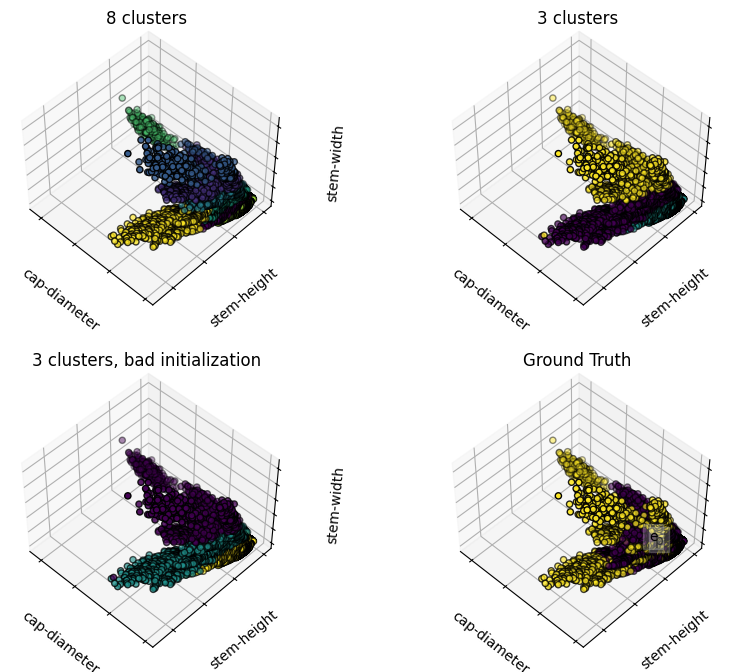

In [11]:
estimators = [
    ("k_means_mushrooms_8", KMeans(n_clusters=8)),
    ("k_means_mushrooms_3", KMeans(n_clusters=3)),
    ("k_means_mushrooms_bad_init", KMeans(n_clusters=3, n_init=1, init="random")),
]
fig = plt.figure(figsize=(10, 8))
titles = ["8 clusters", "3 clusters", "3 clusters, bad initialization"]
for idx, ((name, est), title) in enumerate(zip(estimators, titles)):
    ax = fig.add_subplot(2, 2, idx + 1, projection="3d", elev=48, azim=134)
    est.fit(X)
    labels = est.labels_

    ax.scatter(X["cap-diameter"], X["stem-height"], X["stem-width"], c=labels.astype(float), edgecolor="k")

    ax.xaxis.set_ticklabels([])
    ax.yaxis.set_ticklabels([])
    ax.zaxis.set_ticklabels([])
    ax.set_xlabel("cap-diameter")
    ax.set_ylabel("stem-height")
    ax.set_zlabel("stem-width")
    ax.set_title(title)

# Plot the ground truth
ax = fig.add_subplot(2, 2, 4, projection="3d", elev=48, azim=134)

for name, label in [(vals[0], 0), (vals[1], 1)]:
   ds = dataset[dataset["class"]==name]
   ax.text3D(
        ds["cap-diameter"].mean(),
        ds["stem-height"].mean(),
        ds["stem-width"].mean(),
        name,
        horizontalalignment="center",
        bbox=dict(alpha=0.2, edgecolor="w", facecolor="w"),
    )

ax.scatter(X["cap-diameter"], X["stem-height"], X["stem-width"], c=y, edgecolor="k")

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])
ax.set_xlabel("cap-diameter")
ax.set_ylabel("stem-height")
ax.set_zlabel("stem-width")
ax.set_title("Ground Truth")

plt.subplots_adjust(wspace=0.25, hspace=0.25)
plt.show()

Метрики

In [12]:
from sklearn import metrics
from sklearn.metrics.cluster import adjusted_rand_score
n_clusters = np.arange(2, 21)

In [13]:
best_metric = [0, 10000, 0, []]
silhouette_score_values = []
adjusted_rand_score_values = []
for n in n_clusters:
    clusterer = KMeans(n_clusters=n, max_iter=10, n_init=10)
    clusterer.fit(X)
    y_pred = clusterer.predict(X)

    score1 = metrics.silhouette_score(X, y_pred, sample_size=2000)
    silhouette_score_values.append(score1)

    score2 = metrics.adjusted_rand_score(y, y_pred)
    adjusted_rand_score_values.append(score2)

    if score1 < best_metric[1] and score2 > best_metric[2]:
          best_metric[1] = score1
          best_metric[2] = score2
          best_metric[3] = clusterer.cluster_centers_
          best_metric[0] = n

In [14]:
best_metric

[np.int64(3),
 np.float64(0.4793591931350438),
 0.04105696811017018,
 array([[ 9.1886332 ,  8.10388149, 17.67427129],
        [19.10680361,  9.57541082, 40.99820975],
        [ 3.89193076,  5.23226223,  5.66478634]])]

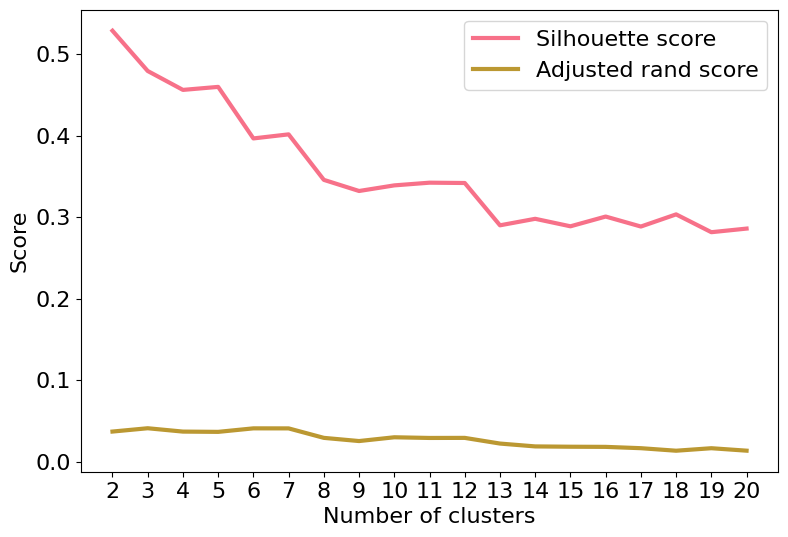

In [15]:

plt.figure(figsize=(9, 6))
plt.plot(n_clusters, silhouette_score_values, linewidth=3, label='Silhouette score')
plt.plot(n_clusters, adjusted_rand_score_values, linewidth=3, label='Adjusted rand score')
plt.xlabel('Number of clusters', size=16)
plt.ylabel('Score', size=16)
plt.xticks(n_clusters, size=16)
plt.yticks(size=16)
plt.legend(loc='best', fontsize=16)
plt.show()

Иерархическая кластеризация

In [16]:
from scipy.cluster.hierarchy import linkage, dendrogram

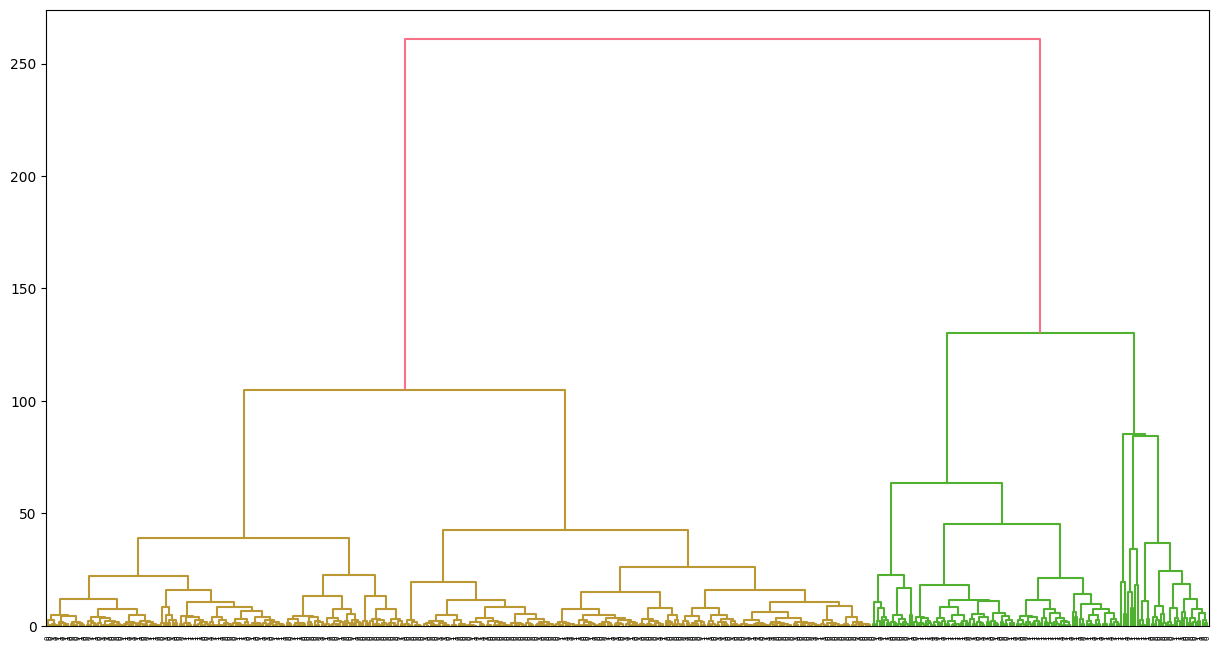

In [20]:
sample_size = 500  # уменьшаем до 500
#np.random.seed(42)
sample_indices = np.random.choice(len(X), sample_size, replace=False)

samples = X.iloc[sample_indices]
sample_labels = y.iloc[sample_indices]
# Реализация иерархической кластеризации при помощи функции linkage
mergings = linkage(samples, method='ward')
plt.figure(figsize=(15, 8))
# Строим дендрограмму, указав параметры удобные для отображения
dendrogram(mergings,
           labels=list(sample_labels),
           leaf_rotation=90,
           leaf_font_size=5,
           )
plt.show()

DBSCAN

In [21]:
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn import datasets

In [22]:
mins = X.shape[1]

['y', 'b', 'g', 'r']


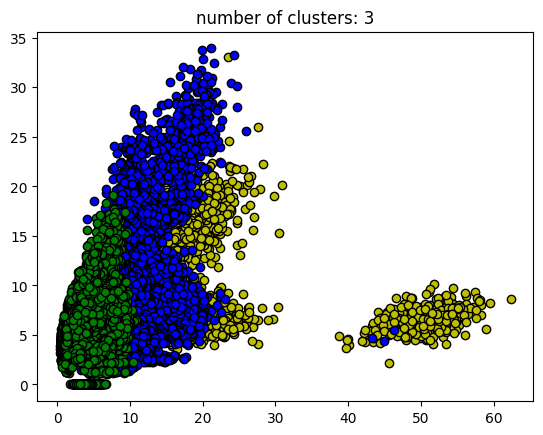

In [25]:
db = DBSCAN(eps=0.5, min_samples=12).fit(X)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels_db = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)

# Plot result
unique_labels = set(labels)
colors = ['y', 'b', 'g', 'r']
print(colors)
for k, col in zip(unique_labels, colors):
    if k == -1:
        col = 'k'

    class_member_mask = (labels == k)

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(xy["cap-diameter"], xy["stem-height"], 'o', markerfacecolor=col,
            markeredgecolor='k', markersize=6)

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(xy["cap-diameter"], xy["stem-height"], 'o', markerfacecolor=col,
            markeredgecolor='k', markersize=6)

plt.title('number of clusters: %d' % n_clusters_)
plt.show()

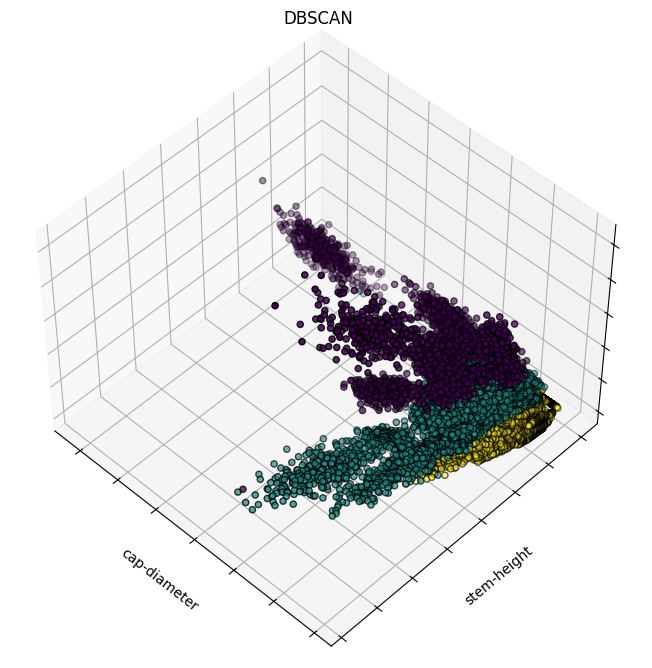

In [26]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection='3d', elev=48, azim=134)

ax.scatter(X["cap-diameter"], X["stem-height"], X["stem-width"], c=labels.astype(float), edgecolor="k")

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])
ax.set_xlabel("cap-diameter")
ax.set_ylabel("stem-height")
ax.set_zlabel("stem-width")
ax.set_title("DBSCAN")

plt.show()

In [27]:
# evaluation metrics
sc = metrics.silhouette_score(X, labels)
print("Silhouette Coefficient:%0.2f" % sc)
ari = adjusted_rand_score(y, labels)
print("Adjusted Rand Index: %0.2f" % ari)

Silhouette Coefficient:0.49
Adjusted Rand Index: 0.04
